In [ ]:
import pandas as pd
import numpy as np
import re, nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer,recall_score,precision_score,f1_score,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier

In [3]:
df = pd.read_csv("../dataset/spam.csv", encoding="latin1")

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.shape

(5572, 5)

We observe column 2,3,4 are unnecessary ones added. We proceed by dropping them first.

In [7]:
df=df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape

(5572, 2)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Our data has no missing values.

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df=df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

Although duplicates across different lables may be useful, but here we have duplicated entire rows.Not useful.

In [14]:
df['mssg']=df['v2']
df['target']=df['v1']

In [15]:
df.head()

,v1,v2,mssg,target
0,ham,"Go until jurong point, crazy.. Available only ...","Go until jurong point, crazy.. Available only ...",ham
1,ham,Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...,ham
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor... U c already then say...,ham
4,ham,"Nah I don't think he goes to usf, he lives aro...","Nah I don't think he goes to usf, he lives aro...",ham


In [16]:
df=df.drop(columns=["v1","v2"])

In [17]:
df.head()

,mssg,target
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


So, we renamed our columns.

In [78]:
df[["mssg", "target"]].to_csv("../dataset/clean_data.csv", index=False)

In [18]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

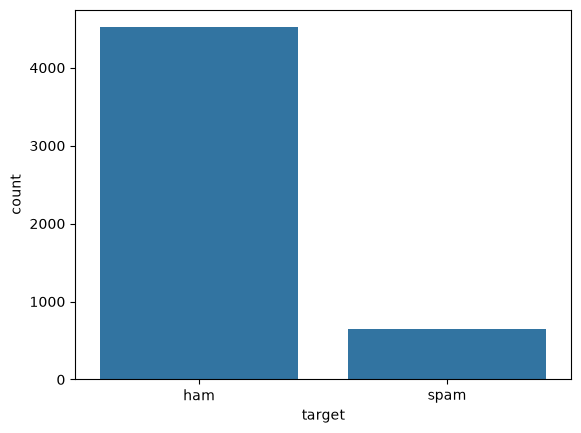

In [19]:
import seaborn as sns
sns.countplot(data=df, x="target")

We observe highly unbalanced data. There are few spam and more normal data.

In [20]:
df['mssg_len']=df['mssg'].str.len()

In [21]:
df.head()

,mssg,target,mssg_len
0,"Go until jurong point, crazy.. Available only ...",ham,111
1,Ok lar... Joking wif u oni...,ham,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,155
3,U dun say so early hor... U c already then say...,ham,49
4,"Nah I don't think he goes to usf, he lives aro...",ham,61


In [22]:
df['mssg_len'].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: mssg_len, dtype: float64

In [23]:
df.groupby('target')['mssg_len'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


Spam messages tend to be longer than ham messages.

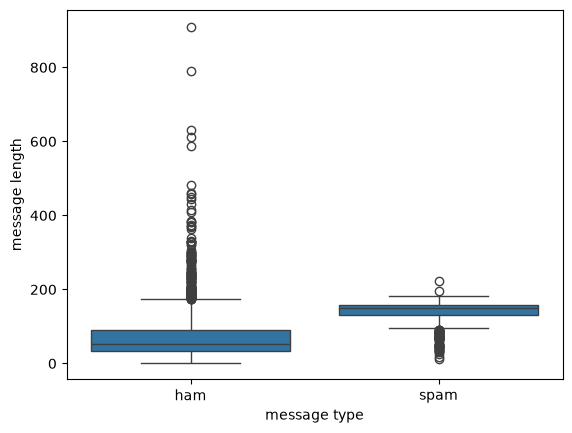

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df,x="target",y="mssg_len")
plt.xlabel("message type")
plt.ylabel("message length")
plt.show()

Ham messages have more variability than spam. IQR is fairly large. Many high end outliers. Spam are longer. IQr is lower, Similar lengths, no high end outliers.

Ham are shorter on avg but more variable. Spam are longer on avg and more concentrated.

In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Amina
[nltk_data]     Fatima\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [27]:
from collections import Counter
ham_words=" ".join(df[df['target']=="ham"]["mssg"]).split()
spam_words=" ".join(df[df['target']=="spam"]["mssg"]).split()
print("Ham: ",Counter(ham_words).most_common(20))
print("Spam: ",Counter(spam_words).most_common(20))

Ham:  [('to', 1450), ('you', 1412), ('I', 1349), ('the', 954), ('a', 884), ('i', 714), ('and', 712), ('in', 677), ('u', 576), ('my', 570), ('is', 561), ('me', 513), ('for', 452), ('of', 452), ('that', 387), ('it', 357), ('your', 346), ('have', 337), ('on', 334), ('at', 316)]
Spam:  [('to', 522), ('a', 314), ('your', 171), ('call', 163), ('the', 160), ('or', 155), ('for', 152), ('2', 151), ('you', 150), ('is', 130), ('Call', 116), ('on', 112), ('have', 110), ('from', 109), ('and', 102), ('&', 89), ('with', 86), ('ur', 86), ('of', 79), ('FREE', 75)]


In [28]:
df["word_count"] = df["mssg"].str.split().str.len()
df.groupby("target")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,14.134632,11.116240,1.0,7.0,11.0,18.0,171.0
spam,653.0,23.681470,5.967672,2.0,22.0,25.0,28.0,35.0


<Axes: xlabel='target', ylabel='word_count'>

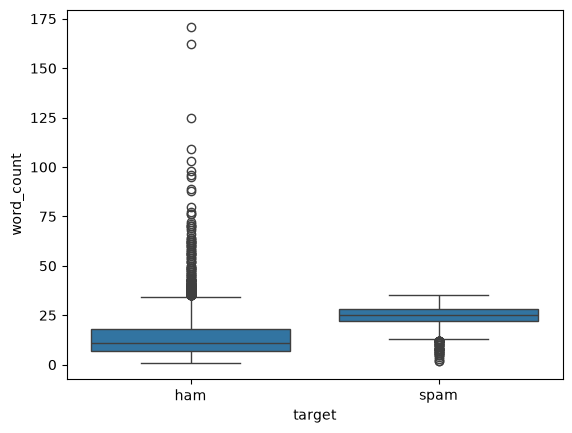

In [29]:
sns.boxplot(data=df, x="target", y="word_count")

Similar inference as length. Ham has more words, and more variability is no. of words. Spam has more outliers on lower end.

In [30]:
df["special_char_count"] = df["mssg"].apply(
    lambda x: sum(not c.isalnum() and not c.isspace() for c in x)
)
df.groupby("target")["special_char_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,3.891275,4.531656,0.0,1.0,3.0,5.0,133.0
spam,653.0,6.062787,3.548616,0.0,3.0,6.0,8.0,26.0


<Axes: xlabel='target', ylabel='special_char_count'>

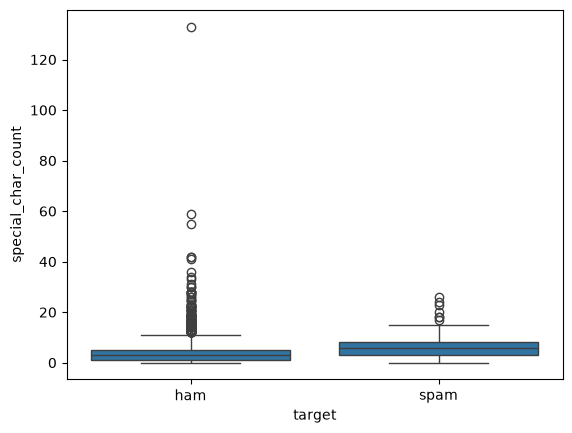

In [31]:
sns.boxplot(data=df, x="target", y="special_char_count")

Ham has essentially has no. of special_Char, but that is also contributed to it by long lengths. The full stops, commas etc. As for spam,it has more special characters.

In [32]:
df["digit_count"] = df["mssg"].apply(
    lambda x: sum(c.isdigit() for c in x)
)
df.groupby('target')['digit_count'].describe()


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,0.290301,1.011825,0.0,0.0,0.0,0.0,23.0
spam,653.0,15.447167,8.924653,0.0,9.0,16.0,22.0,47.0


<Axes: xlabel='target', ylabel='digit_count'>

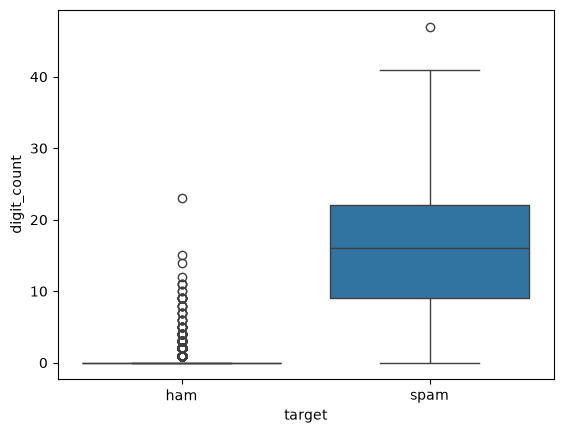

In [33]:
sns.boxplot(data=df, x="target", y="digit_count")

Here we observe the IQR is almost zero. Most ham messages dont have any numbers at all, but IQR of spam is very high. Almost all spam have 20 to 22 no.'s in them.

In [34]:
df["uppercase_count"] = df["mssg"].apply(
    lambda x: sum(c.isupper() for c in x)
)
df.groupby('target')['uppercase_count'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
ham,4516.0,3.904119,10.154046,0.0,1.0,2.0,3.0,127.0
spam,653.0,15.246554,12.645794,0.0,7.0,13.0,20.0,128.0


<Axes: xlabel='target', ylabel='uppercase_count'>

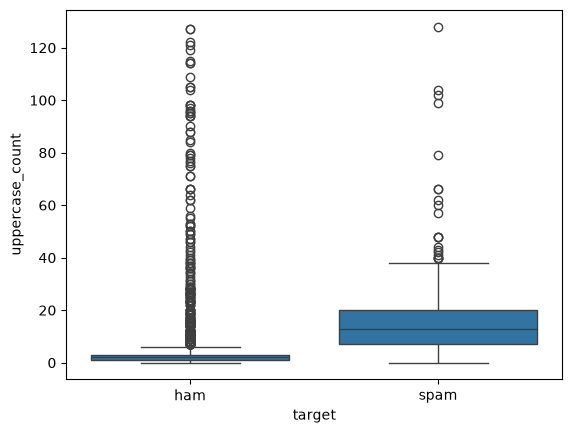

In [35]:
sns.boxplot(data=df,x="target",y="uppercase_count")

Again IQR of ham is visually smaller than spam indicating most ham messages dont have many uppercases, only some outliers have them. We need to note that ham has more datapoints than spam. Spam has higher IQR indicating higher use of caps in almost many spam messages. 

In [36]:
from nltk.util import ngrams

def get_ngrams(texts, n, top_n=20):
    words = " ".join(texts).lower().split()
    n_grams = ngrams(words, n)
    return Counter(n_grams).most_common(top_n)

In [37]:
spam_ngrams = get_ngrams(
    df[df["target"] == "spam"]["mssg"],
    n=2,
    top_n=20
)
spam_ngrams = [
    (" ".join(gram), count)
    for gram, count in spam_ngrams
]

spam_ngrams

[('you have', 63),
 ('your mobile', 43),
 ('have won', 43),
 ('please call', 39),
 ('this is', 38),
 ('to contact', 36),
 ('won a', 33),
 ('to claim', 32),
 ('you are', 27),
 ('stop to', 26),
 ('or a', 23),
 ('u have', 22),
 ('will be', 21),
 ('a new', 21),
 ('for your', 20),
 ('cash or', 20),
 ('po box', 20),
 ('to receive', 19),
 ('attempt to', 19),
 ('with a', 18)]

In [38]:
spam_n3grams = get_ngrams(
    df[df["target"] == "spam"]["mssg"],
    n=3,
    top_n=20
)
spam_n3grams = [
    (" ".join(gram), count)
    for gram, count in spam_n3grams
]

spam_n3grams

[('you have won', 28),
 ('have won a', 26),
 ('prize guaranteed. call', 17),
 ('urgent! your mobile', 16),
 ('account statement for', 15),
 ('trying to contact', 14),
 ('cash or a', 14),
 ('reply or call', 14),
 ('from land line.', 14),
 ('2nd attempt to', 14),
 ('this is the', 14),
 ('is the 2nd', 14),
 ('å£1000 cash or', 13),
 ('we are trying', 13),
 ('are trying to', 13),
 ('draw shows that', 13),
 ('shows that you', 13),
 ('valid 12hrs only', 13),
 ('attempt to contact', 13),
 ('private! your 2003', 13)]

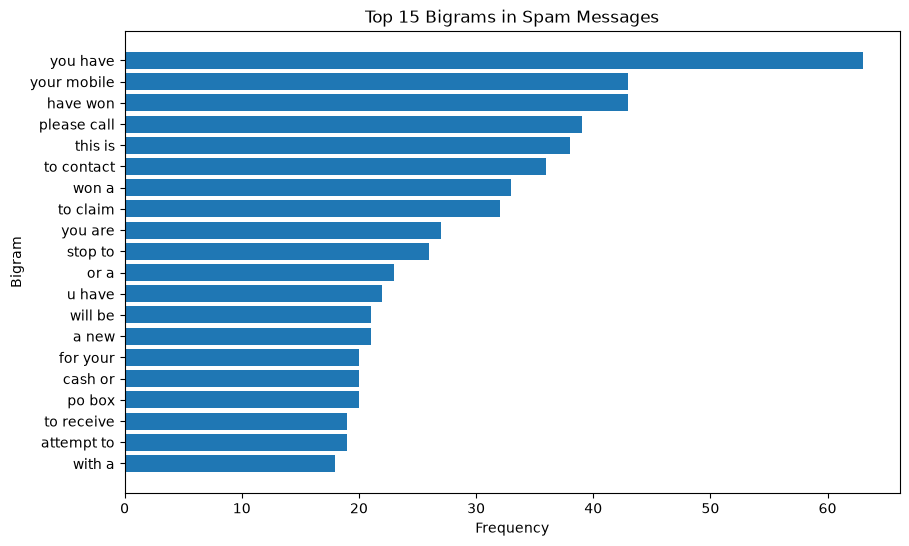

In [39]:
grams, counts = zip(*spam_ngrams)

plt.figure(figsize=(10, 6))
plt.barh(grams[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 15 Bigrams in Spam Messages")
plt.show()

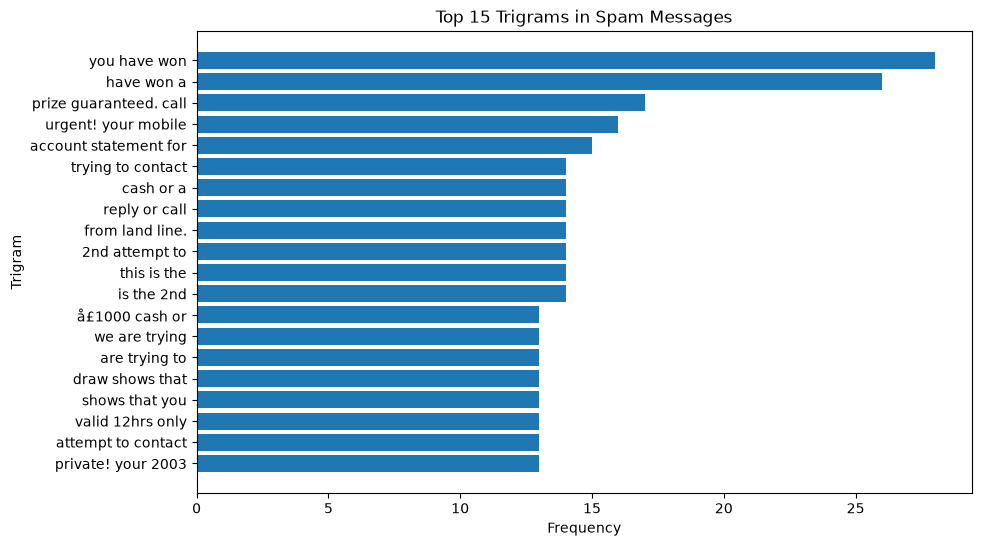

In [40]:
grams, counts = zip(*spam_n3grams)

plt.figure(figsize=(10, 6))
plt.barh(grams[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 15 Trigrams in Spam Messages")
plt.show()

In [41]:
ham_ngrams = get_ngrams(
    df[df["target"] == "ham"]["mssg"],
    n=2,
    top_n=20
)
ham_ngrams = [
    (" ".join(gram), count)
    for gram, count in ham_ngrams
]
ham_ngrams

[('are you', 144),
 ('i am', 115),
 ('have a', 103),
 ('do you', 86),
 ('you are', 85),
 ('i will', 82),
 ('i have', 81),
 ('in the', 80),
 ('if you', 77),
 ('want to', 75),
 ('going to', 71),
 ('and i', 69),
 ('have to', 68),
 ('but i', 68),
 ('i can', 67),
 ('i was', 66),
 ('to be', 64),
 ('in a', 64),
 ('need to', 60),
 ('to get', 59)]

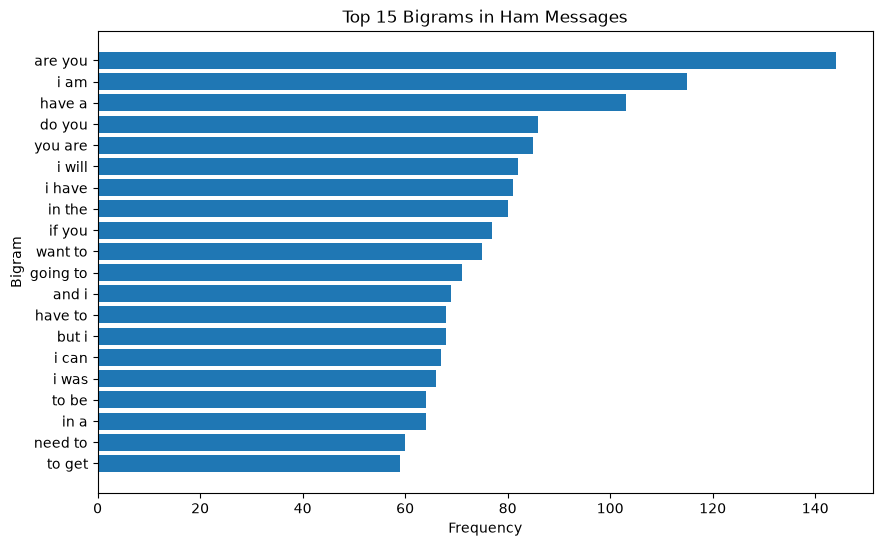

In [42]:
grams, counts = zip(*ham_ngrams)

plt.figure(figsize=(10, 6))
plt.barh(grams[::-1], counts[::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 15 Bigrams in Ham Messages")
plt.show()

In [43]:
X=df['mssg']
Y=df['target']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2,stratify=Y)
tf_idf=TfidfVectorizer(stop_words='english')

In [44]:
X_train_tf=tf_idf.fit_transform(X_train)
X_test_tf=tf_idf.transform(X_test)

In [45]:
print(X_train.shape,X_train_tf.shape)
print(X_test.shape,X_test_tf.shape)

(4135,) (4135, 7429)
(1034,) (1034, 7429)


It created 7429 no. of vocabulary features.

In [46]:
print(type(X_train_tf))

<class 'scipy.sparse._csr.csr_matrix'>


It is a sparse matrix,coz for 7429 features, not every message has all of them.

In [47]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
def print_cf(y_pred):
    cf=confusion_matrix(Y_test,y_pred=y_pred,labels=['ham','spam'])
    disp=ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=['ham','spam'])
    disp.plot()
    plt.show()

Accuracy= 0.9613152804642167
Precision= 0.9690721649484536
Recall= 0.7175572519083969


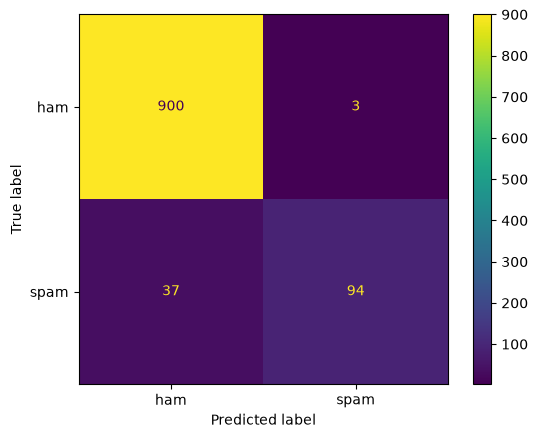

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
lr=LogisticRegression()
def fit_model(model):
    model.fit(X_train_tf,Y_train)
    y_pred=model.predict(X_test_tf)
    print("Accuracy=",accuracy_score(Y_test,y_pred))
    print("Precision=",precision_score(Y_test,y_pred,pos_label="spam"))
    print("Recall=",recall_score(Y_test,y_pred,pos_label="spam"))
    print_cf(y_pred)
fit_model(lr)

recall is 71%, of 100 spams we catch only 71. precision, when model says it is spam, it is correct 96% of times.

We lose 29% of our spam messages. 

Model passes off quite a few spam as ham. TN-yellow, FP,FN,TN. There are 37 FN. Our model is hesitant to call a message spam. When this is ok is when an ham may get marked as spam, here in this case our precision becomes important. But since our precision is already excellent, we might as well try to improve our recall.

Now we use bigrams, and trigrams to try improve out recall. Coz they have spam specific phrases.

In [49]:
tf_idf2=TfidfVectorizer(stop_words='english',ngram_range=(1,3))
X_train_tf2=tf_idf2.fit_transform(X_train)
X_test_tf2=tf_idf2.transform(X_test)

In [50]:
lr2=LogisticRegression()
lr2.fit(X_train_tf2,Y_train)
y_pred2=lr2.predict(X_test_tf2)
print("Accuracy=",accuracy_score(Y_test,y_pred2))
print("Precision=",precision_score(Y_test,y_pred2,pos_label="spam"))
print("Recall=",recall_score(Y_test,y_pred2,pos_label="spam"))

Accuracy= 0.9429400386847195
Precision= 0.9736842105263158
Recall= 0.5648854961832062


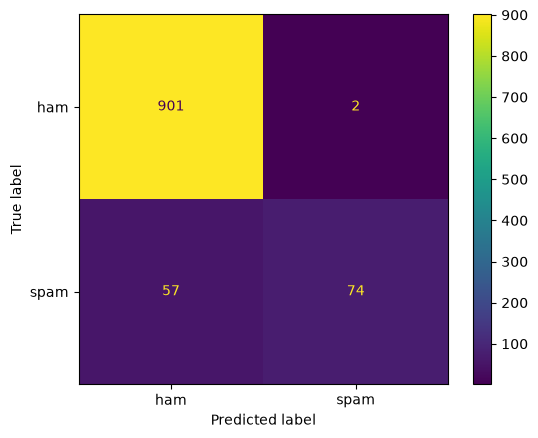

In [51]:
print_cf(y_pred2)

Since bigrams, or trigrams dont tend to improve but rather worsen our recall, we will try other models.

Accuracy= 0.9700193423597679
Precision= 1.0
Recall= 0.7633587786259542


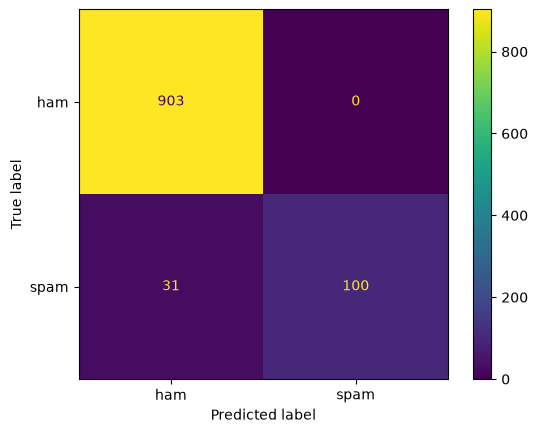

In [52]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
svc=SVC(kernel='linear')
fit_model(nb)

Accuracy= 0.9864603481624759
Precision= 0.968
Recall= 0.9236641221374046


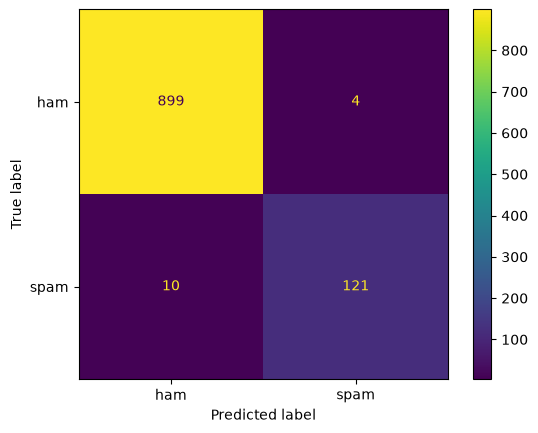

In [53]:
fit_model(svc)

So, for unigram tf-idf we observe svc is highest is precision,recall and accuracy too. NB while it increased precision to 100%, recall didnt improve much.

Accuracy= 0.9661508704061895
Precision= 0.9137931034482759
Recall= 0.8091603053435115


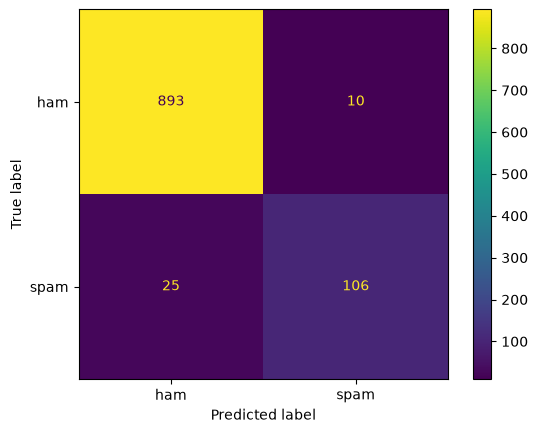

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
dt=DecisionTreeClassifier()
gb=GradientBoostingClassifier()
ad=AdaBoostClassifier()
rf=RandomForestClassifier()
fit_model(dt)

Accuracy= 0.9584139264990329
Precision= 0.9680851063829787
Recall= 0.6946564885496184


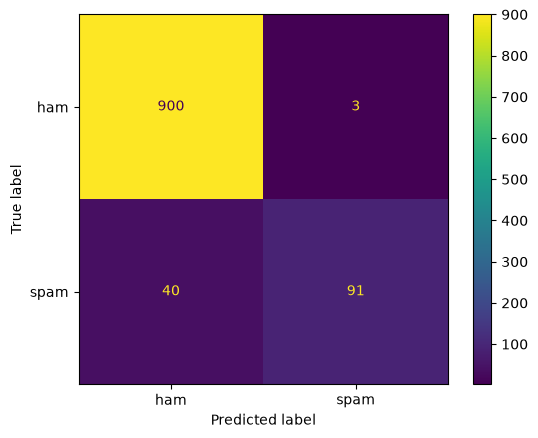

In [55]:
fit_model(gb)

Accuracy= 0.9806576402321083
Precision= 0.9911504424778761
Recall= 0.8549618320610687


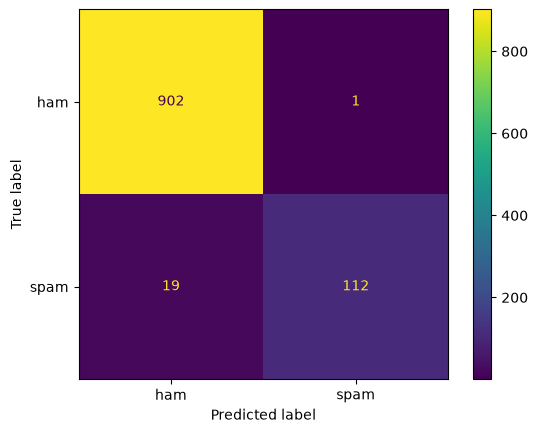

In [56]:
fit_model(rf)

Accuracy= 0.9061895551257253
Precision= 0.9722222222222222
Recall= 0.26717557251908397


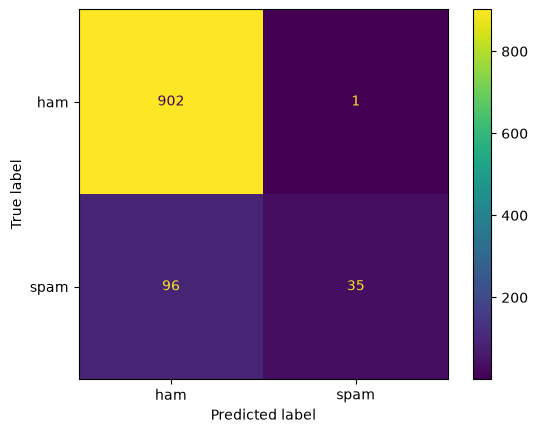

In [57]:
fit_model(ad)

Top contenders are: SVC, Logistic, RandomForest, NB, DT

In [58]:
recall_spam = make_scorer(
    recall_score,
    pos_label="spam"
)
precision_spam = make_scorer(
    precision_score,
    pos_label="spam"
)
f1_spam = make_scorer(
    f1_score,
    pos_label="spam"
)
def print_cv(model):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words='english')),
        ("model", model)
    ])
    scoring={
        "accuracy": "accuracy",
        "recall": recall_spam,
        "precision": precision_spam,
        "f1": f1_spam
    }
    scores=cross_validate(
        pipe,
        X_train,
        Y_train,
        scoring=scoring,
        cv=5
    )
    print("Accuracy =", scores["test_accuracy"].mean())
    print("Recall =", scores["test_recall"].mean())
    print("Precision =", scores["test_precision"].mean())
    print("F1 Score =", scores["test_f1"].mean())


In [59]:
print_cv(LogisticRegression())

Accuracy = 0.9516324062877872
Recall = 0.6265018315018315
Precision = 0.9852176464584609
F1 Score = 0.7655173467410017


In [60]:
print_cv(SVC())

Accuracy = 0.9746070133010883
Recall = 0.8084615384615386
Precision = 0.9884249471458773
F1 Score = 0.8892412713213755


In [61]:
print_cv(rf)

Accuracy = 0.9678355501813785
Recall = 0.752948717948718
Precision = 0.9902725626988532
F1 Score = 0.8550274655733203


In [62]:
print_cv(nb)

Accuracy = 0.9605804111245465
Recall = 0.6878205128205128
Precision = 1.0
F1 Score = 0.8144188099482218


In [63]:
print_cv(dt)

Accuracy = 0.9574365175332528
Recall = 0.776025641025641
Precision = 0.8757532031182891
F1 Score = 0.8214494372976965


Thus svc is our final winner.

In [64]:
from sklearn.model_selection import GridSearchCV
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english')),
    ("model", SVC())
])
param={
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf", "sigmoid"],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "model__class_weight": [None, "balanced"]
}
grid=GridSearchCV(pipe,param,scoring=f1_spam,cv=5,n_jobs=-1)
grid.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...os_label=spam)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versi

In [67]:
print(grid.best_params_)
print(grid.best_estimator_)
print(grid.best_score_)

{'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('model', SVC(C=10, class_weight='balanced', gamma=0.1))])
0.922821680305742


In [69]:
best_model=grid.best_estimator_
Y_pred=best_model.predict(X_test)
print("Test Accuracy:",accuracy_score(Y_test,Y_pred))
print("Test Recall:", recall_score(Y_test, Y_pred, pos_label="spam"))
print("Test Precision:", precision_score(Y_test, Y_pred, pos_label="spam"))
print("Test F1:", f1_score(Y_test, Y_pred, pos_label="spam"))

Test Accuracy: 0.9893617021276596
Test Recall: 0.9389312977099237
Test Precision: 0.9761904761904762
Test F1: 0.9571984435797666


These seem to be really good metrics.

In [71]:
cv_scores = cross_validate(
    grid.best_estimator_,
    X_train,
    Y_train,
    scoring={
        "accuracy": "accuracy",
        "recall": recall_spam,
        "precision": precision_spam,
        "f1": f1_spam
    },
    cv=5
)

print("CV Accuracy =", cv_scores["test_accuracy"].mean())
print("CV Recall =", cv_scores["test_recall"].mean())
print("CV Precision =", cv_scores["test_precision"].mean())
print("CV F1 =", cv_scores["test_f1"].mean())

CV Accuracy = 0.981378476420798
CV Recall = 0.8850549450549451
CV Precision = 0.9643213188854919
CV F1 = 0.922821680305742


Now we do roc auc

In [72]:
from sklearn.metrics import auc,roc_curve,roc_auc_score
Y_score=best_model.decision_function(X_test)
roc_auc=roc_auc_score(Y_test.map({'ham':0,'spam':1}),Y_score)
print(roc_auc)


0.9934357907906639


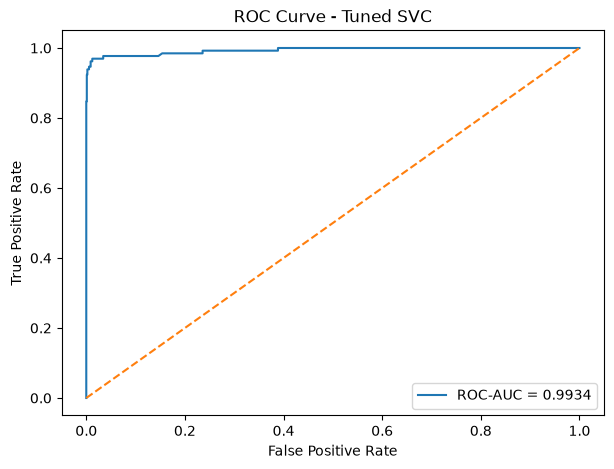

In [73]:
fpr, tpr, thresholds = roc_curve(
    Y_test.map({"ham": 0, "spam": 1}),
    Y_score
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned SVC")
plt.legend()
plt.show()

In [74]:
from sklearn.model_selection import cross_val_score

cv_roc_auc = cross_val_score(
    grid.best_estimator_,
    X_train,
    Y_train,
    scoring="roc_auc",
    cv=5
)

print("CV ROC-AUC:", cv_roc_auc)
print("Mean CV ROC-AUC:", cv_roc_auc.mean())

CV ROC-AUC: [0.9888951  0.99408182 0.99877647 0.99351009 0.98405224]
Mean CV ROC-AUC: 0.991863140977749


The model has close cv and test auc values. It has excellent ability to distinguish spam and ham.

Now we can serialize the model.